# Evaluation Labels

This notebook keeps the standard evaluation separate and runs a targeted label-query evaluation on a selected S3DIS area.

For each room prefix in the selected area, it samples up to 3 rooms. For each sampled room, it samples 3 labels that are actually present in the room and evaluates cosine-similarity query behavior for those labels.

### 1. Setup Repo & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

REPO_DIR = '/content/Deep_learning_project'
DRIVE_ROOT = '/content/drive/MyDrive/DL_Project'
EVAL_FEATURES_NAME = 's3dis_area4'
DRIVE_FEATURES_DIR = f'{DRIVE_ROOT}/features/{EVAL_FEATURES_NAME}'
LOCAL_FEATURES_ROOT = '/content/local_features'
LOCAL_FEATURES_DIR = f'{LOCAL_FEATURES_ROOT}/{EVAL_FEATURES_NAME}'
BRANCH = 'dev/eval-demo'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Gandata/Deep_learning_project.git {REPO_DIR}

Mounted at /content/drive
Cloning into '/content/Deep_learning_project'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 431 (delta 86), reused 88 (delta 42), pack-reused 289 (from 1)
Receiving objects: 100% (431/431), 40.24 MiB | 35.37 MiB/s, done.
Resolving deltas: 100% (253/253), done.


In [2]:
%cd {REPO_DIR}
!git restore configs/train_mlp_s3dis.yaml notebooks/pyproject.toml notebooks/evaluation_labels.ipynb src/evaluate_labels.py
!git fetch origin
!git checkout -B {BRANCH} origin/{BRANCH}
!git pull --no-edit origin {BRANCH}
!git branch --show-current
!git log -1 --oneline

/content/Deep_learning_project
error: pathspec 'notebooks/evaluation_labels.ipynb' did not match any file(s) known to git
error: pathspec 'src/evaluate_labels.py' did not match any file(s) known to git
Branch 'dev/eval-demo' set up to track remote branch 'dev/eval-demo' from 'origin'.
Switched to a new branch 'dev/eval-demo'
From https://github.com/Gandata/Deep_learning_project
 * branch            dev/eval-demo -> FETCH_HEAD
Already up to date.
dev/eval-demo
0663412 (HEAD -> dev/eval-demo, origin/dev/eval-demo) Se creó con Colab


### 2. Wire Drive Paths and Copy Features Locally

We keep `data/` and `checkpoints/` on Drive, but copy the selected feature folder to local runtime storage for faster evaluation.

In [3]:
%cd {REPO_DIR}
!rm -f data checkpoints features pretrained
!ln -sf {DRIVE_ROOT}/data ./data
!ln -sf {DRIVE_ROOT}/checkpoints ./checkpoints
!mkdir -p {LOCAL_FEATURES_ROOT}
!rm -rf {LOCAL_FEATURES_DIR}
!cp -r {DRIVE_FEATURES_DIR} {LOCAL_FEATURES_ROOT}/
!ln -sf {LOCAL_FEATURES_ROOT} ./features
!echo Selected feature folder: {EVAL_FEATURES_NAME}
!readlink -f ./features/{EVAL_FEATURES_NAME}
!du -sh {LOCAL_FEATURES_DIR}
!ls -lh ./checkpoints/mlp_s3dis | tail

/content/Deep_learning_project
Selected feature folder: s3dis_area4
/content/local_features/s3dis_area4
18G	/content/local_features/s3dis_area4
-rw------- 1 root root 12M May  6 09:07 epoch_033.pth
-rw------- 1 root root 12M May  6 09:18 epoch_034.pth
-rw------- 1 root root 12M May  6 09:30 epoch_035.pth
-rw------- 1 root root 12M May  6 09:41 epoch_036.pth
-rw------- 1 root root 12M May  6 09:53 epoch_037.pth
-rw------- 1 root root 12M May  6 10:04 epoch_038.pth
-rw------- 1 root root 12M May  6 10:16 epoch_039.pth
-rw------- 1 root root 12M May  6 10:27 epoch_040.pth
-rw------- 1 root root   0 May  6 10:27 history.json
-rw------- 1 root root 12M May  6 10:27 last_model.pth


### 3. Setup Environment & Hugging Face Token

In [4]:
%cd /content/Deep_learning_project/notebooks

from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
with open('.env', 'w') as f:
    f.write(f'HF_TOKEN={HF_TOKEN}\n')

!uv python install 3.10.12
!uv sync --python 3.10.12

/content/Deep_learning_project/notebooks
Installed Python 3.10.12 in 836ms
 + cpython-3.10.12-linux-x86_64-gnu (python3.10)
Using CPython 3.10.12
Creating virtual environment at: .venv
Resolved 147 packages in 4.95s
Prepared 140 packages in 57.87s
Installed 141 packages in 280ms
 + addict==2.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + anyio==4.13.0
 + attrs==26.1.0
 + blinker==1.9.0
 + brotli==1.2.0
 + camtools==0.1.8
 + ccimport==0.4.4
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + configargparse==1.7.5
 + contourpy==1.3.2
 + cumm-cu120==0.4.11
 + cycler==0.12.1
 + dash==4.1.0
 + dotenv==0.9.9
 + exceptiongroup==1.3.1
 + fast-pytorch-kmeans==0.2.2
 + fastapi==0.136.1
 + fastjsonschema==2.21.2
 + filelock==3.29.0
 + fire==0.7.1
 + flask==3.1.3
 + fonttools==4.62.1
 + fsspec==2026.4.0
 + ftfy==6.3.1
 + gradio==6.14.0
 + gradio-client==2.5.0
 + groovy==0.1.2
 + h11==0.16.0
 + hf-gradio==0.4.1
 + hf-xet==1.5.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + hugg

### 4. Run Label-Query Evaluation

This keeps the standard full-feature evaluation untouched. Here we only use the selected area, sample up to 3 rooms per room prefix, then sample 3 labels present in each room and evaluate cosine-similarity query behavior.

In [5]:
CONFIG_PATH = '/content/Deep_learning_project/configs/train_mlp_s3dis.yaml'
RESULTS_DIR = '/content/drive/MyDrive/DL_Project/results/evaluation/04b'
CHECKPOINT_NAME = 'last_model.pth'
CHECKPOINT_PATH = f'/content/Deep_learning_project/checkpoints/mlp_s3dis/{CHECKPOINT_NAME}'
EVAL_BATCH_SIZE = 16384
ROOMS_PER_PREFIX = 3
LABELS_PER_ROOM = 3
RANDOM_SEED = 42

print('Config:', CONFIG_PATH)
print('Results dir:', RESULTS_DIR)
print('Features dir:', f'/content/Deep_learning_project/features/{EVAL_FEATURES_NAME}')
print('Checkpoint:', CHECKPOINT_PATH)
print('Batch size:', EVAL_BATCH_SIZE)
print('Rooms per prefix:', ROOMS_PER_PREFIX)
print('Labels per room:', LABELS_PER_ROOM)
print('Seed:', RANDOM_SEED)

!PYTHONPATH=/content/Deep_learning_project uv run python /content/Deep_learning_project/src/evaluate_labels.py --config {CONFIG_PATH} --features_dir /content/Deep_learning_project/features/{EVAL_FEATURES_NAME} --checkpoint {CHECKPOINT_PATH} --batch_size {EVAL_BATCH_SIZE} --results_dir {RESULTS_DIR} --rooms_per_prefix {ROOMS_PER_PREFIX} --labels_per_room {LABELS_PER_ROOM} --seed {RANDOM_SEED}

Config: /content/Deep_learning_project/configs/train_mlp_s3dis.yaml
Results dir: /content/drive/MyDrive/DL_Project/results/evaluation/04b
Features dir: /content/Deep_learning_project/features/s3dis_area4
Checkpoint: /content/Deep_learning_project/checkpoints/mlp_s3dis/last_model.pth
Batch size: 16384
Rooms per prefix: 3
Labels per room: 3
Seed: 42
/content/Deep_learning_project/src/evaluate_labels.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are expli

### 5. Visualize the Saved Label-Query Results

Area summary file: /content/drive/MyDrive/DL_Project/results/evaluation/04b/area_level/s3dis_area4_last_model_summary.json
Prefix metrics file: /content/drive/MyDrive/DL_Project/results/evaluation/04b/prefix_level/s3dis_area4_last_model_prefix_metrics.csv
Room metrics file: /content/drive/MyDrive/DL_Project/results/evaluation/04b/room_level/s3dis_area4_last_model_room_metrics.csv
Query metrics file: /content/drive/MyDrive/DL_Project/results/evaluation/04b/query_level/s3dis_area4_last_model_query_metrics.csv


,0
features_dir,/content/Deep_learning_project/features/s3dis_...
checkpoint,/content/Deep_learning_project/checkpoints/mlp...
clip_model,ViT-B-32
clip_pretrained,openai
normalize_features,True
batch_size,16384
rooms_per_prefix,3
labels_per_room,3
seed,42
num_candidate_rooms,49


,room_prefix,num_selected_rooms,mean_average_precision,mean_topk_iou,mean_cosine_gap
2,hallway,3,0.387752,0.236575,-0.006295
1,conferenceRoom,3,0.356313,0.268468,-0.001381
4,office,3,0.285524,0.206812,-0.002291
5,storage,3,0.238506,0.102338,0.000774
0,WC,3,0.220479,0.111111,-0.009018
3,lobby,2,0.182716,0.129785,-0.010928


,room_file,room_prefix,mean_average_precision,mean_topk_iou,mean_cosine_gap
3,Area_4_conferenceRoom_1.npz,conferenceRoom,0.643405,0.538841,0.008058
16,Area_4_storage_3.npz,storage,0.498541,0.259106,0.010915
2,Area_4_WC_4.npz,WC,0.426677,0.333333,-0.006090
11,Area_4_office_12.npz,office,0.415579,0.296729,0.014197
8,Area_4_hallway_9.npz,hallway,0.404963,0.262195,-0.005677
12,Area_4_office_5.npz,office,0.398711,0.323707,0.006701
6,Area_4_hallway_11.npz,hallway,0.379632,0.263383,-0.011340
7,Area_4_hallway_12.npz,hallway,0.378661,0.184146,-0.001869
10,Area_4_lobby_2.npz,lobby,0.345536,0.259570,0.001509
4,Area_4_conferenceRoom_2.npz,conferenceRoom,0.296042,0.264731,-0.005805


,room_file,label_name,average_precision,roc_auc,topk_iou,positive_mean_cosine,negative_mean_cosine,cosine_gap
7,Area_4_WC_4.npz,chair,1.000000,1.000000,1.000000,0.041356,0.013841,0.027516
37,Area_4_office_5.npz,wall,0.990405,0.993662,0.968496,0.040432,0.003794,0.036639
11,Area_4_conferenceRoom_1.npz,chair,0.983752,0.999421,0.977127,0.041191,0.010039,0.031152
19,Area_4_hallway_11.npz,wall,0.946056,0.933035,0.789421,0.037075,0.015621,0.021454
25,Area_4_hallway_9.npz,wall,0.939006,0.936837,0.786574,0.037544,0.014090,0.023454
49,Area_4_storage_3.npz,wall,0.931200,0.975784,0.775687,0.038763,-0.008562,0.047324
35,Area_4_office_12.npz,chair,0.923694,0.975912,0.890186,0.039164,0.012769,0.026395
30,Area_4_lobby_2.npz,wall,0.911827,0.955354,0.763247,0.034448,-0.014847,0.049295
9,Area_4_conferenceRoom_1.npz,wall,0.902423,0.824974,0.639395,0.027014,0.003207,0.023807
22,Area_4_hallway_12.npz,wall,0.839616,0.841481,0.552437,0.032573,0.011486,0.021087


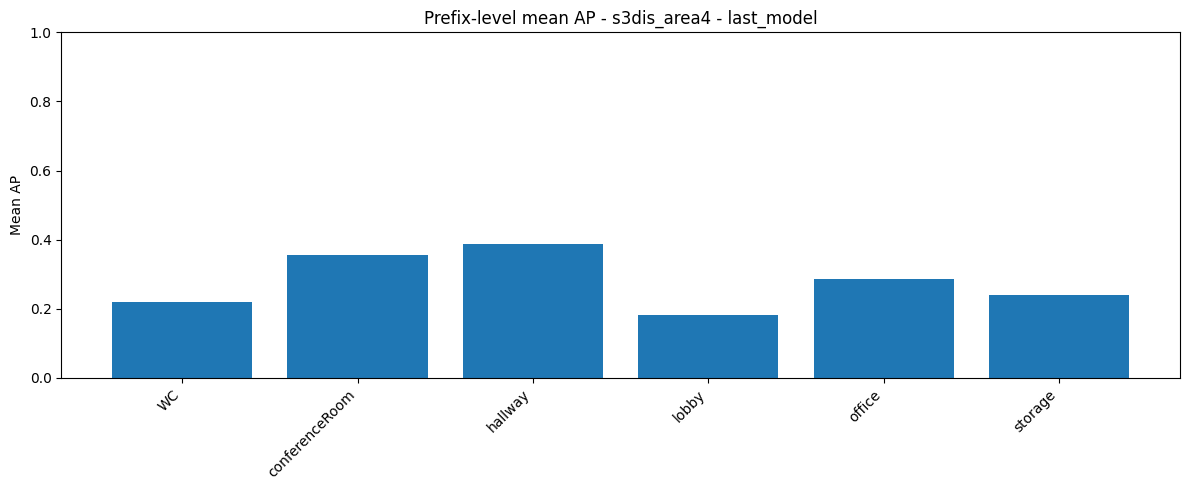

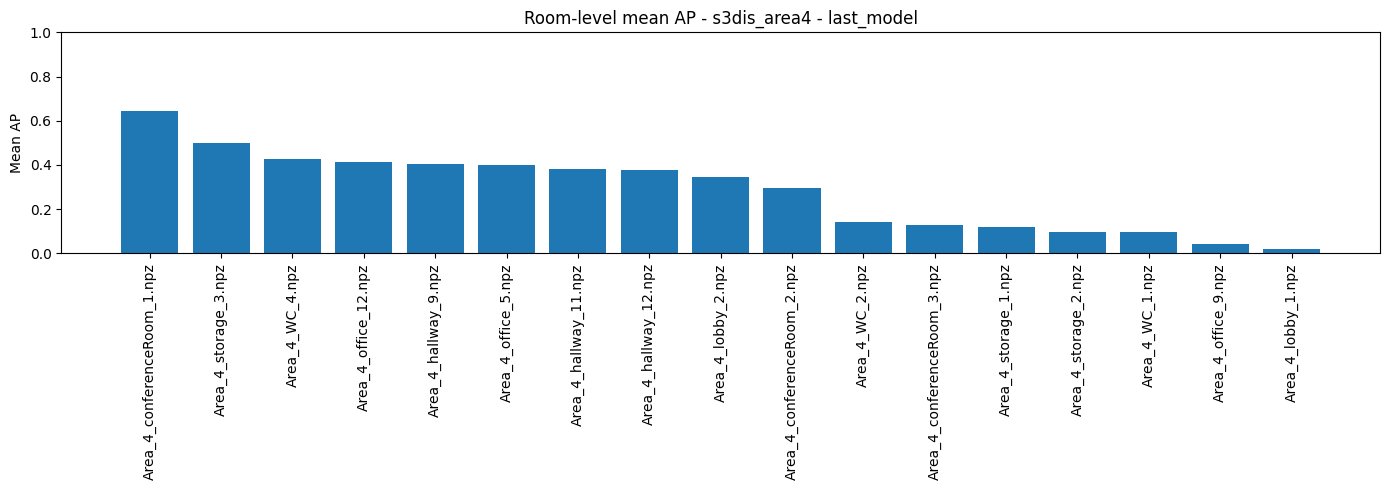

In [6]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

AREA_JSON_PATH = Path(RESULTS_DIR) / 'area_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_summary.json'
PREFIX_CSV_PATH = Path(RESULTS_DIR) / 'prefix_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_prefix_metrics.csv'
ROOM_CSV_PATH = Path(RESULTS_DIR) / 'room_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_room_metrics.csv'
QUERY_CSV_PATH = Path(RESULTS_DIR) / 'query_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_query_metrics.csv'

print('Area summary file:', AREA_JSON_PATH)
print('Prefix metrics file:', PREFIX_CSV_PATH)
print('Room metrics file:', ROOM_CSV_PATH)
print('Query metrics file:', QUERY_CSV_PATH)

with AREA_JSON_PATH.open('r', encoding='utf-8') as handle:
    area_summary = json.load(handle)

prefix_df = pd.read_csv(PREFIX_CSV_PATH)
room_df = pd.read_csv(ROOM_CSV_PATH)
query_df = pd.read_csv(QUERY_CSV_PATH)

display(pd.Series(area_summary))
display(prefix_df[['room_prefix', 'num_selected_rooms', 'mean_average_precision', 'mean_topk_iou', 'mean_cosine_gap']].sort_values('mean_average_precision', ascending=False))
display(room_df[['room_file', 'room_prefix', 'mean_average_precision', 'mean_topk_iou', 'mean_cosine_gap']].sort_values('mean_average_precision', ascending=False).head(15))
display(query_df[['room_file', 'label_name', 'average_precision', 'roc_auc', 'topk_iou', 'positive_mean_cosine', 'negative_mean_cosine', 'cosine_gap']].sort_values('average_precision', ascending=False).head(20))

plt.figure(figsize=(12, 5))
plt.bar(prefix_df['room_prefix'], prefix_df['mean_average_precision'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean AP')
plt.ylim(0.0, 1.0)
plt.title(f'Prefix-level mean AP - {EVAL_FEATURES_NAME} - {Path(CHECKPOINT_NAME).stem}')
plt.tight_layout()
plt.show()

room_plot_df = room_df.sort_values('mean_average_precision', ascending=False).reset_index(drop=True)
plt.figure(figsize=(14, 5))
plt.bar(room_plot_df['room_file'], room_plot_df['mean_average_precision'])
plt.xticks(rotation=90)
plt.ylabel('Mean AP')
plt.ylim(0.0, 1.0)
plt.title(f'Room-level mean AP - {EVAL_FEATURES_NAME} - {Path(CHECKPOINT_NAME).stem}')
plt.tight_layout()
plt.show()